<a href="https://colab.research.google.com/github/NataCode13/Challenge-3-Mod-Predict/blob/main/TelecomX_Modelado_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Modelo predictivo de evasión (Churn)

El objetivo de este proyecto es construir modelos predictivos que permitan anticipar la evasión de clientes, identificar los factores que más influyen en este comportamiento y proponer acciones de retención basadas en la evidencia.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay)

#cargar CSV
df = pd.read_csv("datos_tratados.csv")
df.head()

#revisar estructura
df.info()
df.shape
df.isna().sum().sort_values(ascending=False).head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [11]:
#Paso de eliminar columnas que no aporten valor
df_model = df.copy()

columnas_eliminar = ["customerID"]
for col in columnas_eliminar:
    if col in df_model.columns:
        df_model.drop(columns=col, inplace=True)

# opcional: quitar variable redundante
if "Cuentas_Diarias" in df_model.columns:
    df_model.drop(columns=["Cuentas_Diarias"], inplace=True)

df_model.head()

#Definir la variable objetivo
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})
df_model["Churn"].value_counts(dropna=False)
df_model = df_model.dropna(subset=["Churn"]).copy()
df_model["Churn"] = df_model["Churn"].astype(int)

In [12]:
##Calcular proporción de evasiones y activos, para ver desbalances
proporcion = df_model["Churn"].value_counts(normalize=True) * 100
conteo = df_model["Churn"].value_counts()

print("Conteo:")
print(conteo)
print("\nProporción (%):")
print(proporcion.round(2))

Conteo:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporción (%):
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


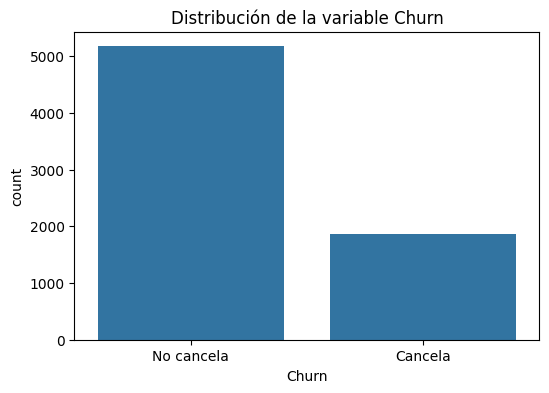

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_model, x="Churn")
plt.title("Distribución de la variable Churn")
plt.xticks([0,1], ["No cancela", "Cancela"])
plt.show()

Matriz de correlación

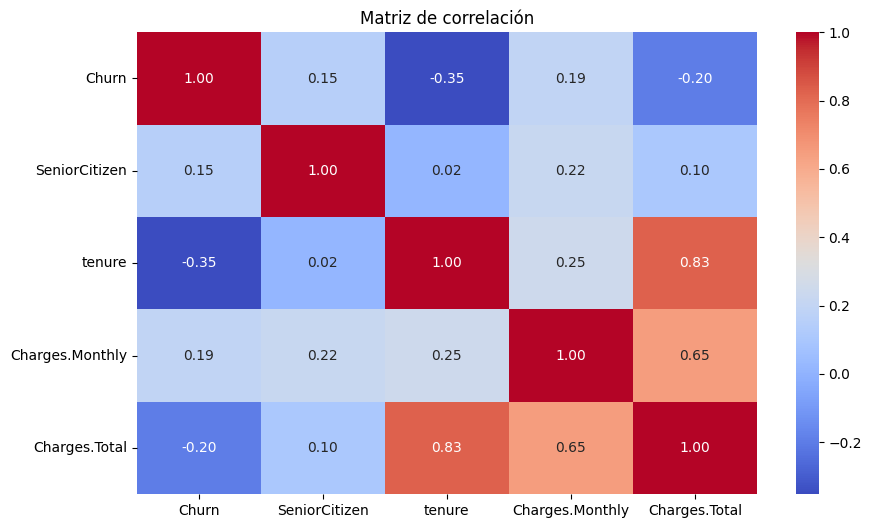

In [14]:
num_cols = df_model.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(10,6))
sns.heatmap(df_model[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

Relación entre cancelación y tiempo de contrato / gasto total

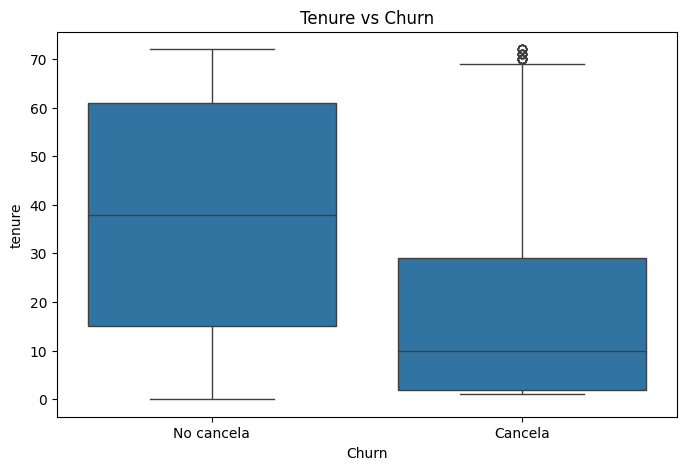

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_model, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.xticks([0,1], ["No cancela", "Cancela"])
plt.show()

Separación de variables predictoras y objetivo

In [16]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

categoricas = X.select_dtypes(include=["object"]).columns.tolist()
numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categóricas:", categoricas)
print("Numéricas:", numericas)

Categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numéricas: ['SeniorCitizen', 'tenure', 'Charges.Monthly', 'Charges.Total']


Dividir entrenamiento y prueba

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (5634, 19) (5634,)
Test: (1409, 19) (1409,)


Preprocesamiento Regresión Logística

In [18]:
preprocessor_log = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numericas),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), categoricas)
    ]
)

Preprocesamiento Random Forest

In [19]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numericas),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), categoricas)
    ]
)

Entrenar los 2 modelos

In [20]:
#modelo regresión logística
modelo_log = Pipeline([
    ("preprocessor", preprocessor_log),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

modelo_log.fit(X_train, y_train)

#modelo random forest
modelo_rf = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

modelo_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'Charges.Monthly',
                                                   'Charges.Total']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'Par...
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=5,
                                        min_samples_split=10, n_estimators=300,
                                        random_state=42))])

Evaluación de métricas

In [21]:
def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    resultados = {
        "Modelo": nombre,
        "Accuracy_train": accuracy_score(y_train, y_pred_train),
        "Accuracy_test": accuracy_score(y_test, y_pred_test),
        "Precision_test": precision_score(y_test, y_pred_test),
        "Recall_test": recall_score(y_test, y_pred_test),
        "F1_test": f1_score(y_test, y_pred_test)
    }

    print(f"\n===== {nombre} =====")
    print(pd.Series(resultados))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred_test))

    cm = confusion_matrix(y_test, y_pred_test)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot()
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

    return resultados


===== Regresión Logística =====
Modelo            Regresión Logística
Accuracy_train               0.752574
Accuracy_test                0.739532
Precision_test               0.506024
Recall_test                  0.786096
F1_test                      0.615707
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



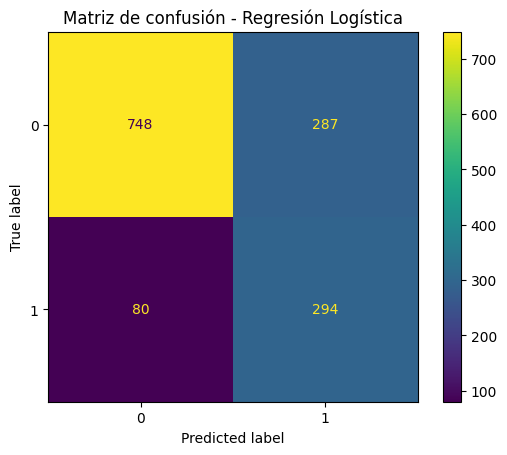


===== Random Forest =====
Modelo            Random Forest
Accuracy_train         0.797835
Accuracy_test          0.766501
Precision_test         0.542373
Recall_test            0.770053
F1_test                0.636464
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.77      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



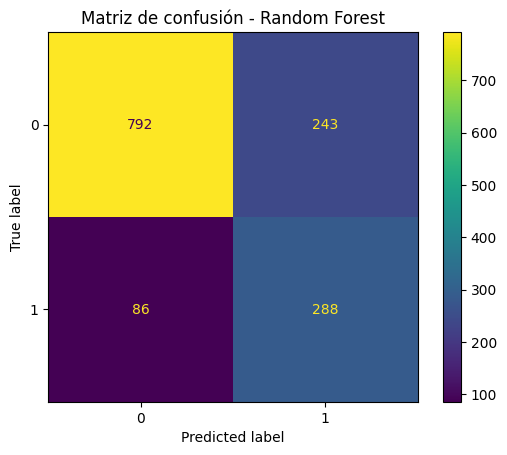

In [22]:
res_log = evaluar_modelo("Regresión Logística", modelo_log, X_train, X_test, y_train, y_test)
res_rf = evaluar_modelo("Random Forest", modelo_rf, X_train, X_test, y_train, y_test)

In [23]:
resultados_df = pd.DataFrame([res_log, res_rf])
resultados_df

,Modelo,Accuracy_train,Accuracy_test,Precision_test,Recall_test,F1_test
0,Regresión Logística,0.752574,0.739532,0.506024,0.786096,0.615707
1,Random Forest,0.797835,0.766501,0.542373,0.770053,0.636464


Análisis de modelos

In [24]:
feature_names_log = modelo_log.named_steps["preprocessor"].get_feature_names_out()
coeficientes = modelo_log.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Variable": feature_names_log,
    "Coeficiente": coeficientes
})

coef_df["AbsCoef"] = coef_df["Coeficiente"].abs()

top_positivos = coef_df.sort_values("Coeficiente", ascending=False).head(10)
top_negativos = coef_df.sort_values("Coeficiente", ascending=True).head(10)

print("Variables que más aumentan la probabilidad de churn:")
display(top_positivos[["Variable", "Coeficiente"]])

print("Variables que más reducen la probabilidad de churn:")
display(top_negativos[["Variable", "Coeficiente"]])

Variables que más aumentan la probabilidad de churn:


,Variable,Coeficiente
3,num__Charges.Total,0.619028
9,cat__InternetService_Fiber optic,0.563700
21,cat__PaymentMethod_Electronic check,0.419867
19,cat__PaperlessBilling_Yes,0.341421
8,cat__MultipleLines_Yes,0.237547
15,cat__StreamingTV_Yes,0.182714
2,num__Charges.Monthly,0.138952
16,cat__StreamingMovies_Yes,0.089483
0,num__SeniorCitizen,0.079961
20,cat__PaymentMethod_Credit card (automatic),0.026672


Variables que más reducen la probabilidad de churn:


,Variable,Coeficiente
18,cat__Contract_Two year,-1.390367
1,num__tenure,-1.295844
17,cat__Contract_One year,-0.697054
10,cat__InternetService_No,-0.695656
7,cat__PhoneService_Yes,-0.642463
14,cat__TechSupport_Yes,-0.433004
11,cat__OnlineSecurity_Yes,-0.351485
12,cat__OnlineBackup_Yes,-0.201680
6,cat__Dependents_Yes,-0.163224
13,cat__DeviceProtection_Yes,-0.090410


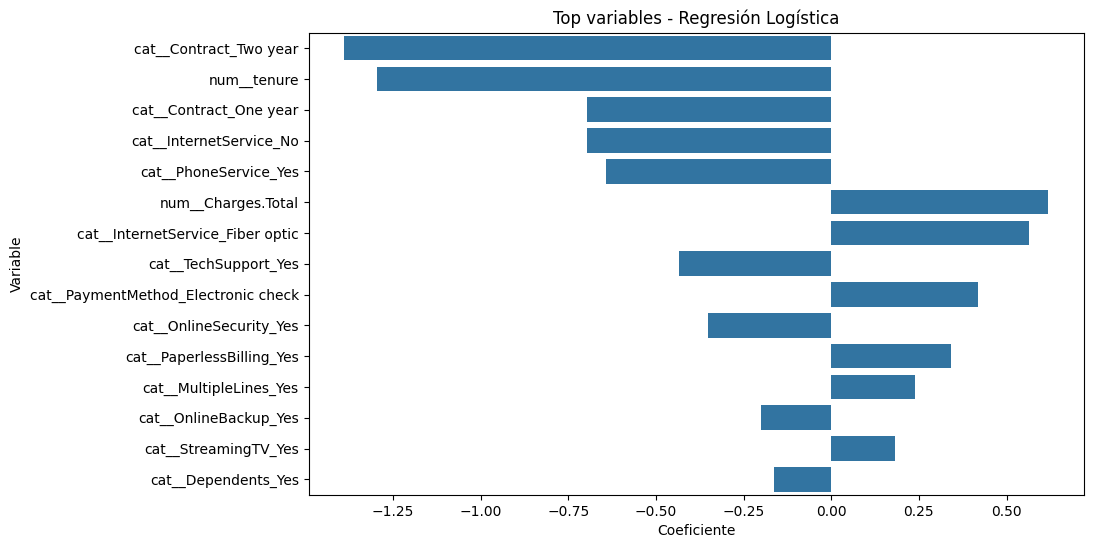

In [25]:
top_coef = coef_df.sort_values("AbsCoef", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=top_coef, x="Coeficiente", y="Variable")
plt.title("Top variables - Regresión Logística")
plt.show()

Importancia de variables en Random Forest

In [26]:
feature_names_rf = modelo_rf.named_steps["preprocessor"].get_feature_names_out()
importancias = modelo_rf.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({
    "Variable": feature_names_rf,
    "Importancia": importancias
}).sort_values("Importancia", ascending=False)

display(imp_df.head(15))

,Variable,Importancia
1,num__tenure,0.192052
3,num__Charges.Total,0.129078
18,cat__Contract_Two year,0.122562
9,cat__InternetService_Fiber optic,0.104238
2,num__Charges.Monthly,0.102443
21,cat__PaymentMethod_Electronic check,0.067128
10,cat__InternetService_No,0.055763
17,cat__Contract_One year,0.049099
14,cat__TechSupport_Yes,0.029193
11,cat__OnlineSecurity_Yes,0.024931


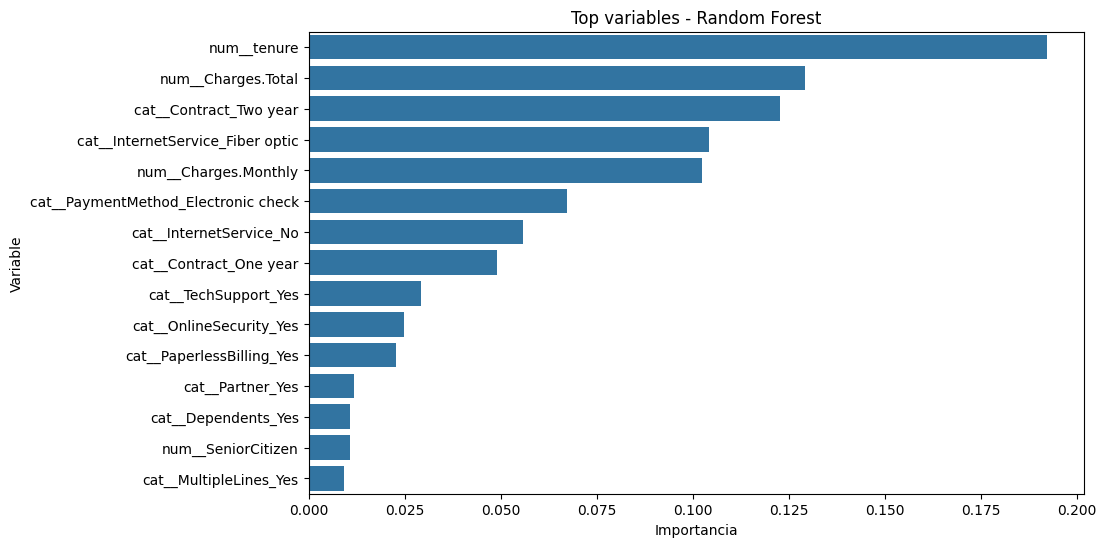

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(data=imp_df.head(15), x="Importancia", y="Variable")
plt.title("Top variables - Random Forest")
plt.show()

#Informe final


In [30]:

from IPython.display import Markdown, display

mejor_modelo = resultados_df.iloc[0]
texto = f'''
# Informe de resultados

## Modelos entrenados
Se entrenaron dos modelos:
- Regresión Logística, usando normalización por ser sensible a la escala.
- Random Forest, sin normalización, ya que los árboles no dependen de la magnitud de las variables.

El modelo con mejor F1-score fue **{mejor_modelo['Modelo']}**.

## Variables más relevantes
Los factores que más se repiten entre los modelos son:
- Contrato mes a mes (`Month-to-month`)
- Menor antigüedad (`tenure`)
- Servicio de internet por fibra óptica
- Método de pago `Electronic check`
- Menor acceso a servicios como `TechSupport` y `OnlineSecurity`

## Conclusiones
Los resultados muestran que la cancelación no ocurre de forma aleatoria. Se concentra sobre todo en clientes nuevos, con contratos mes a mes, mayor exposición a fibra óptica y métodos de pago menos automatizados. Esto indica que la empresa puede anticipar la evasión identificando estos perfiles de riesgo.

## Recomendaciones
1. Diseñar campañas de retención temprana para clientes con poca antigüedad.
2. Incentivar migración desde contratos mensuales a contratos anuales.
3. Revisar experiencia, precio o calidad percibida en clientes con fibra óptica.
4. Promover pagos automáticos para reducir fricción operativa.
5. Ofrecer bundles con soporte técnico y seguridad online para reforzar permanencia.
'''

display(Markdown(texto))



# Informe de resultados

## Modelos entrenados
Se entrenaron dos modelos:
- Regresión Logística, usando normalización por ser sensible a la escala.
- Random Forest, sin normalización, ya que los árboles no dependen de la magnitud de las variables.

El modelo con mejor F1-score fue **Regresión Logística**.

## Variables más relevantes
Los factores que más se repiten entre los modelos son:
- Contrato mes a mes (`Month-to-month`)
- Menor antigüedad (`tenure`)
- Servicio de internet por fibra óptica
- Método de pago `Electronic check`
- Menor acceso a servicios como `TechSupport` y `OnlineSecurity`

## Conclusiones
Los resultados muestran que la cancelación no ocurre de forma aleatoria. Se concentra sobre todo en clientes nuevos, con contratos mes a mes, mayor exposición a fibra óptica y métodos de pago menos automatizados. Esto indica que la empresa puede anticipar la evasión identificando estos perfiles de riesgo.

## Recomendaciones
1. Diseñar campañas de retención temprana para clientes con poca antigüedad.
2. Incentivar migración desde contratos mensuales a contratos anuales.
3. Revisar experiencia, precio o calidad percibida en clientes con fibra óptica.
4. Promover pagos automáticos para reducir fricción operativa.
5. Ofrecer bundles con soporte técnico y seguridad online para reforzar permanencia.
